![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# XAI for Transformers: <Method's title>


This Notebook shows ... 

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. To start working on the notebook, click on the following button. This will open this page in the Colab environment, and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-transformer/2-Tutorial_AttentionMaps_Text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Google Colab follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
A folder has been created in your Drive, and you can navigate it through the lefthand panel in Colab. You might also receive an email that informs you about the access on your Google Drive.

In [1]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [2]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [3]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-transformer.txt
# %cd xai-for-transformer

### Imports

In [1]:
import os
import torch
import transformers

import zipfile
import requests
import datasets
import pandas as pd
from sklearn.metrics import balanced_accuracy_score

import shap

# Select the best available device: NVIDIA GPU (CUDA), Apple Silicon GPU (MPS), or CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


---

## Data and Model Loading: The Emotions Dataset

In this notebook, we will work with the **Emotion dataset**, containing English text samples labelled with one of six emotions: **sadness, joy, love, anger, fear,** or **surprise**. Each row consists of a short text and its corresponding emotion label. We will use the predefined dataset split, which contains **16,000 training samples, 2,000 validation samples, and 2,000 test samples**. Our goal is to **predict the emotion expressed in a text** and use SHAP to investigate which words and tokens contribute most strongly to the model's predictions.

**ADD IMAGE HERE**

In the notebook [*1-Tutorial_Transformer_Model.ipynb*](./1-Tutorial_Transformer_Model.ipynb), we introduced the Transformer architecture and the DistilBERT model used throughout this tutorial.

#### Load the Fine-Tuned Transformer Model

We begin by loading the **fine-tuned DistilBERT model** together with its corresponding tokenizer. The model has been fine-tuned on the Emotion dataset to classify text into one of the six emotion classes (**sadness, joy, love, anger, fear,** and **surprise**).

In [2]:
# Fine-tuned DistilBERT emotion weights, hosted as a GitHub Release asset.
# NOTE: the download link becomes active once the weights Release is published.
url = "https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/releases/download/distilbert-emotion-weights/distilbert_emotion_weights.zip"

weights_path = "../data/distilbert-emotion"
zip_path = "../data/distilbert_emotion_weights.zip"
os.makedirs("../data", exist_ok=True)

if not os.path.exists(weights_path):
    # Reuse a local zip if it is already there (e.g. shared for testing),
    # otherwise download it from the Release.
    if not os.path.exists(zip_path):
        with open(zip_path, "wb") as f:
            f.write(requests.get(url).content)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("../data/")

# Load the fine-tuned DistilBERT model and its matching tokenizer. The tokenizer
# converts raw text into token IDs that the model can process, while the model
# predicts one of the six emotion classes from the tokenized input.
model = transformers.AutoModelForSequenceClassification.from_pretrained(weights_path).to(device)
tokenizer = transformers.AutoTokenizer.from_pretrained(weights_path)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

#### Create an Inference Pipeline

Next, we create a Hugging Face **text classification pipeline**, which provides a convenient interface for running inference with the fine-tuned DistilBERT model. The pipeline automatically performs all required preprocessing steps, including tokenization, and processes the input texts in batches to improve inference efficiency before generating predictions. We configure it to return the prediction scores for **all six emotion classes** rather than only the most likely class. While the highest-scoring class is sufficient for evaluating the model's accuracy, SHAP explains the model's output for individual classes and therefore requires access to the complete set of prediction scores.

In [3]:
# Wrap the model and tokenizer into a high-level inference interface that handles
# tokenization, batching, and prediction. Setting top_k=None returns prediction
# scores for all emotion classes, which are required later for SHAP explanations.
classifier_pipeline = transformers.pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    top_k=None,
)

# Store the mapping from predicted emotion names to their numerical class IDs so
# that model predictions can be compared to the ground-truth labels in the dataset.
label2id = model.config.label2id

#### Evaluate the Model

Before interpreting the model with SHAP, it is good practice to verify that it performs well on the prediction task. We therefore evaluate the fine-tuned DistilBERT model on both the **training** and **test** splits of the Emotion dataset.

In [4]:
def evaluate_model(classifier_pipeline, data):
    # Run batched inference on the training texts. For each text, the pipeline
    # returns the prediction scores for all emotion classes. Batching improves
    # inference speed, while truncation ensures that texts exceeding the model's
    # maximum input length are safely shortened.
    predictions = classifier_pipeline(
        data["text"].tolist(),
        batch_size=128,
        truncation=True,
    )

    # Select the highest-scoring predicted emotion for each text, convert the
    # emotion labels to their numerical class IDs, and compare them with the
    # ground-truth labels to compute the balanced classification accuracy.
    predicted_ids = [label2id[max(p, key=lambda x: x["score"])["label"]] for p in predictions]
    accuracy = balanced_accuracy_score(data["emotion"], predicted_ids)
    return accuracy

In [5]:
# Load the training split of the Emotion dataset and store it as a pandas DataFrame
# for later analysis throughout the notebook.
dataset_train = datasets.load_dataset("dair-ai/emotion", split="train")
data_train = pd.DataFrame({"text": dataset_train["text"], "emotion": dataset_train["label"]})

# Evaluate the model on the training data using the helper function defined above.
print(f"TRAIN accuracy: {evaluate_model(classifier_pipeline, data_train):.4f}")

# Repeat the same procedure for the test split to assess how well the model
# generalizes to previously unseen data.
dataset_test = datasets.load_dataset("dair-ai/emotion", split="test")
data_test = pd.DataFrame({"text": dataset_test["text"], "emotion": dataset_test["label"]})
print(f"TEST accuracy: {evaluate_model(classifier_pipeline, data_test):.4f}")

TRAIN accuracy: 0.9498
TEST accuracy: 0.8776


As we can see by the numbers above, our model performs well on the training set and also generalizes well to the independent test set.

**You should keep in mind that interpreting a low-performing model can lead to wrong conclusions.**

## Now, what does my model think is important in the data?

### SHapley Additive exPlanations (SHAP)

**We prepared a small [Introduction to SHAP](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html) for you, to help you understand how this method works.**

*Note: we provide all references [here](https://xai-tutorials.readthedocs.io/en/latest/_model_agnostic_xai/shap.html#references).*

<font color='green'>

#### Question 1: xxx?

<font color='grey'>

#### Your Answer: 
xxx

<font color='green'>

#### Question 2: xxx?

<font color='grey'>

#### Your Answer: 
xxx

Now, let's use SHAP to gain insights into our transformer model. The `shap.Explainer()` class estimates **Shapley values** to explain the predictions of machine learning models. Depending on the model type and input modality, SHAP automatically selects an appropriate explainer. For transformer-based text models, commonly used explainers include:

| Explainer | Comments | 
|-----------|----------|  
| [PartitionExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PartitionExplainer.html) | Efficiently approximates Shapley values by hierarchically grouping tokens. The standard choice for transformer-based NLP models. |
| [PermutationExplainer](https://shap.readthedocs.io/en/latest/generated/shap.PermutationExplainer.html) | Model-agnostic and applicable to any transformer model, but requires substantially more model evaluations than `PartitionExplainer`. |
| [SamplingExplainer](https://shap.readthedocs.io/en/latest/generated/shap.SamplingExplainer.html) | Monte Carlo approximation of Shapley values. More efficient than `KernelExplainer`, but generally less suitable than `PartitionExplainer` for text. |
| [KernelExplainer](https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html) | Fully model-agnostic, but computationally expensive for text because each token is treated as a feature. Primarily useful for small examples. |

All of the above estimate Shapley values using different approximation strategies. In this course, we will focus on `shap.PartitionExplainer()`, which is the recommended explainer for transformer-based text models. It efficiently estimates token-level Shapley values while requiring far fewer model evaluations than the fully model-agnostic approaches. You can read more about each explainer in the [SHAP API](https://shap.readthedocs.io/en/latest/api.html#explainers).

**PartitionExplainer**

**ADD IMAGE HERE**

Text inputs often consist of tens or hundreds of tokens, making the exact computation of Shapley values computationally infeasible. `PartitionExplainer` addresses this challenge by recursively grouping tokens into a hierarchical structure and computing contributions for groups of tokens rather than considering every possible subset individually. This reduces the computational complexity while still providing faithful approximations of the Shapley values.

For transformer models such as DistilBERT, `PartitionExplainer` is typically combined with a **text masker** (`shap.maskers.Text`), which creates perturbed versions of the input sentence by masking selected tokens. The model is then evaluated on these perturbed texts, and the changes in the predicted probabilities are used to estimate the contribution of each token. Tokens with positive SHAP values increase the predicted probability of the selected emotion, whereas tokens with negative SHAP values decrease it. Rather than focusing on the underlying approximation algorithm, we will concentrate on interpreting the resulting token attributions. For a more detailed discussion of `PartitionExplainer` and the approximation of Shapley values, we refer to the SHAP documentation and the book *Interpreting Machine Learning Models With SHAP* ([Molnar, 2022](https://leanpub.com/shap)).

We are now ready to instantiate the SHAP explainer. We reuse the text classification pipeline created earlier as the model to be explained and combine it with a text masker, which generates the perturbed text inputs required by `PartitionExplainer` to estimate token-level Shapley values.

In [6]:
masker = shap.maskers.Text(tokenizer)
explainer = shap.PartitionExplainer(classifier_pipeline, masker)

To illustrate how `PartitionExplainer` works, we first compute SHAP values for a subset of the **training set**. Using training samples is a common choice when exploring a model, as they represent the data distribution the model learned during training. We explain a larger number of texts so that the resulting SHAP values can later be used for both **local explanations** of individual predictions and **global explanations** that summarize the model's behavior across multiple samples.

In [7]:
# Compute SHAP values for the first 100 training samples
shap_values = explainer(data_train["text"][:100])

PartitionExplainer explainer:  47%|████▋     | 47/100 [01:51<02:26,  2.76s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  55%|█████▌    | 55/100 [02:07<01:22,  1.83s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  57%|█████▋    | 57/100 [02:14<01:45,  2.45s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [04:11,  2.62s/it]                         


After computing the SHAP values, we can inspect the resulting `Explanation` object. Its structure differs from the one used for tabular data because text samples are represented by sequences of tokens rather than a fixed set of features.

For **tabular data**, every sample is described by the same set of features. For example, every house in the California Housing dataset has exactly the same eight features:

| Sample | Features |
|--------|----------|
| House 1 | MedInc, HouseAge, AveRooms, ... |
| House 2 | MedInc, HouseAge, AveRooms, ... |
| House 3 | MedInc, HouseAge, AveRooms, ... |

Since every sample shares the same feature space, SHAP can naturally organize the explanations as one matrix of **samples × features** (and an additional output dimension for multiclass models).

For **text data**, the situation is different. Each text consists of its own sequence of **tokens**, and different texts generally contain different numbers of tokens:

| Sample | Tokens |
|--------|--------|
| Text 1 | *I*, *feel*, *happy* |
| Text 2 | *I*, *feel*, *extremely*, *happy*, *today* |
| Text 3 | *Happy!* |

Consequently, there is **no fixed feature matrix**, because every sample has a different set of features (tokens). Instead, SHAP stores **one token-level explanation for each text individually**, together with the corresponding prediction scores for all output classes.

We can now inspect the `Explanation` object produced by SHAP for the first 100 training texts.

In [8]:
# Number of explained texts
print(f"Number of texts: {len(shap_values.values)}")

# Number of emotion classes
print(f"Number of classes: {shap_values.values[0].shape[1]}")

# Number of tokens in the first five texts
for i in range(5):
    print(f"Text {i}: {len(shap_values.data[i])} tokens")

Number of texts: 100
Number of classes: 6
Text 0: 7 tokens
Text 1: 23 tokens
Text 2: 12 tokens
Text 3: 22 tokens
Text 4: 8 tokens


As expected, the explanation contains one entry for each of the 100 texts and provides SHAP values for all six emotion classes. However, the number of tokens differs from one text to another, meaning that each explanation has its own token dimension rather than sharing a common set of features.

*Note: Since DistilBERT uses WordPiece tokenization, some words may be split into multiple tokens. SHAP therefore explains the contribution of individual tokens rather than complete words.*

### Local Explanations with SHAP

Local explanations help us understand **why the model made a specific prediction for an individual text**. Instead of summarizing the model's behavior across the entire dataset, they attribute the prediction to the words or tokens present in a single input.

For each explained text, SHAP assigns a contribution to every token. Positive SHAP values indicate that a token **increases** the model's confidence in the selected emotion, while negative SHAP values indicate that it **decreases** the confidence. The magnitude of the SHAP value reflects how strongly the token influences the prediction.

In the following examples, we use the previously computed SHAP values to inspect individual predictions and identify the words that are most responsible for the model's decisions.

#### Force Plot

The force plot visualizes how individual tokens contribute to a model's prediction **for a single text**. Each token either **increases** or **decreases** the model's output for a selected emotion class. Tokens with positive SHAP values push the prediction towards a higher score, while tokens with negative SHAP values reduce it. The size of each contribution reflects the magnitude of the corresponding SHAP value.

For text classification models with multiple output classes, such as our six-class emotion classifier, the force plot can display explanations for **all emotion classes**. By hovering over or selecting a class, the visualization updates to show how each token contributes specifically to that class's prediction.

The explanation starts from the **base value**, which corresponds to the model's output when **all tokens are masked**. As tokens are progressively unmasked, their SHAP values explain how each token changes the model's output from this baseline to the final prediction for the original input. Since SHAP values are additive, the contributions of all tokens sum to the difference between the base value and the model's final output for the selected emotion class.

In [9]:
# Visualize the token-level SHAP values for the eighth training sentence,
# showing how each word contributes to the prediction of each emotion class.
shap.plots.text(shap_values[7])

While the previous visualization shows the contributions of each token to **all emotion classes**, we can also focus on a **single emotion**. By selecting one output class, the force plot displays only how each token influences the model's prediction for that specific emotion. This is particularly useful when comparing explanations across different emotion classes or when investigating why the model assigned a high or low score to one class.

In [10]:
# Visualize how each token contributes to the prediction of the "fear" class
# for the eighth training sentence.
shap.plots.text(shap_values[7, :, "fear"])

In [11]:
# Visualize how each token contributes to the prediction of the "anger" class
# for the eighth training sentence.
shap.plots.text(shap_values[7, :, "anger"])

When comparing force plots across different emotion classes, remember that each class has its own base value. SHAP values explain how the model moves from that class-specific baseline to the final prediction. As a result, the size of token contributions should always be interpreted relative to the corresponding baseline and final model output, rather than being compared directly across different classes.

### Global Explanations with SHAP

The local explanation plots help us understand **why the model made a specific prediction for an individual text** by highlighting the contribution of each token. However, we are often interested in understanding the model's behavior **across many predictions**. For example, which words are generally the most influential for the model? Are there tokens that consistently contribute to certain emotions?

SHAP addresses these questions by aggregating the local explanations of multiple samples into **global explanations**. By analyzing SHAP values across the dataset, we can identify the tokens that have the greatest overall impact on the model's predictions and gain a broader understanding of the patterns the transformer has learned.

#### Bar Plot

The bar plot provides a concise summary of the **most important tokens** for a selected emotion class across multiple texts. Instead of visualizing the SHAP values for a single prediction, it aggregates the SHAP values over all explained samples by computing the **mean absolute SHAP value** for each token. This highlights the tokens (i.e., words or word pieces) that have the largest overall influence on the model's predictions for the selected class.

Since the SHAP values were computed for many training samples, the resulting bar plot provides a much more representative summary than if only a few examples were used. In general, the more samples included in the aggregation, the more reliable the estimate of the globally important tokens becomes.

When creating global explanations, SHAP first has to combine the token-level explanations from many texts into a common representation. This is performed using methods such as `.mean()`, which are part of SHAP's `Explanation` class. Unlike NumPy's `mean()`, these methods understand the structure of text explanations and preserve the information required for SHAP visualizations.

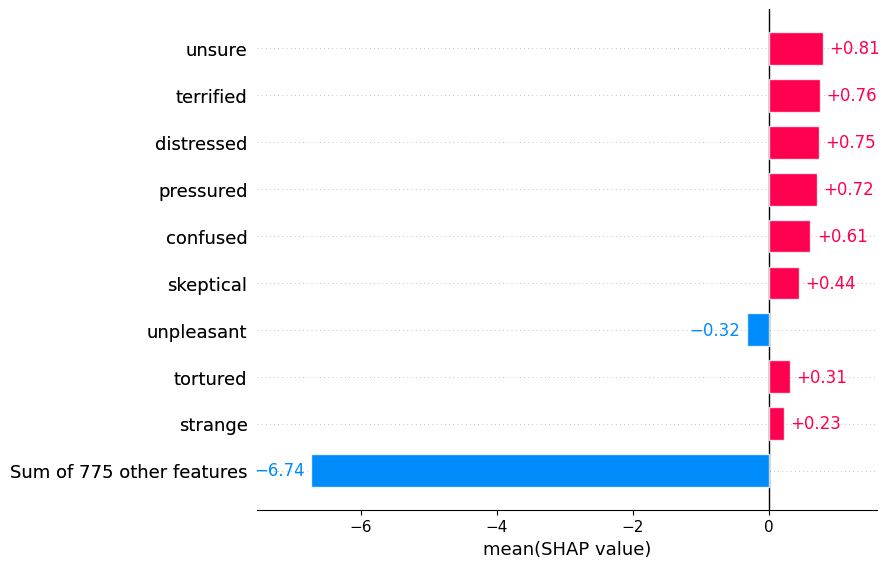

In [12]:
# Aggregate the token-level SHAP explanations for the "fear" class across
# all explained texts and visualize the resulting global token importance.
shap.plots.bar(shap_values[:, :, "fear"].mean(0))

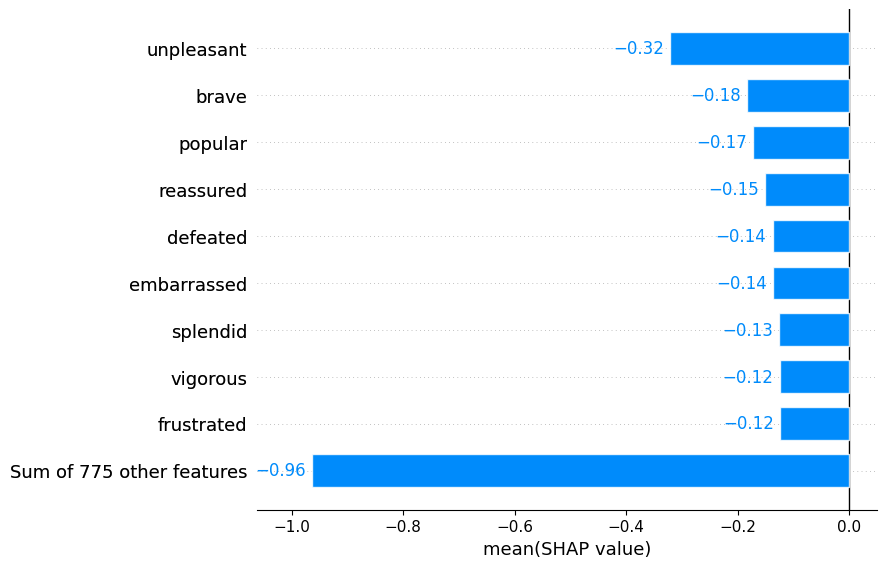

In [13]:
# we can sort the bar chart in decending order
shap.plots.bar(shap_values[:, :, "fear"].mean(0), order=shap.Explanation.argsort)

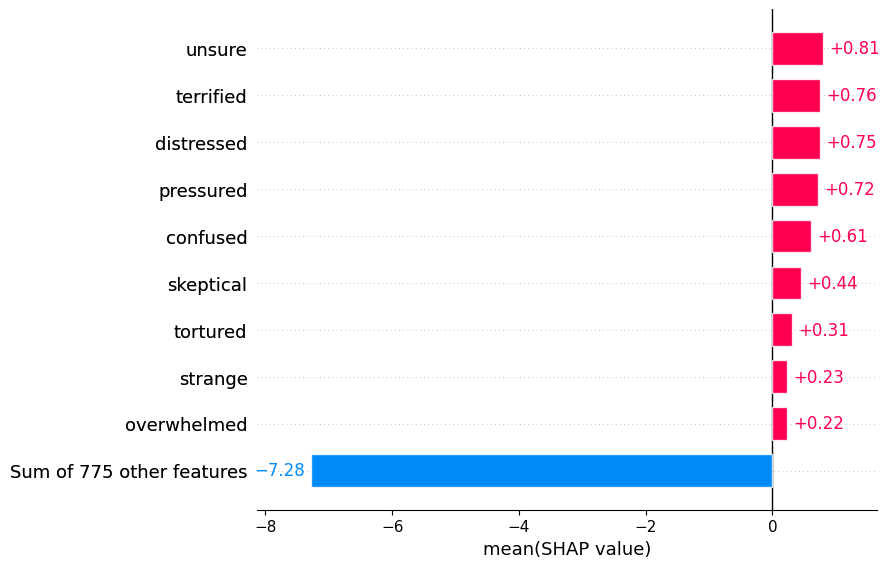

In [14]:
# ...or acending order
shap.plots.bar(shap_values[:, :, "fear"].mean(0), order=shap.Explanation.argsort.flip)

*Note: For transformer-based text models, SHAP primarily supports text (force) plots for local explanations and bar plots for global explanations. Visualizations such as beeswarm and dependence plots are designed for tabular data, where all samples share the same set of features. Since text samples contain variable-length token sequences rather than a fixed feature set, these visualizations are generally not applicable to transformer-based text models.*

<font color='green'>

#### Task: Apply SHAP to the Test Set

In this exercise, you will apply **SHAP** to the **test set** of the trained DistilBERT emotion classifier. Your goal is to investigate whether the explanations obtained on unseen data are consistent with those observed for the training set.

Your task is to:

1. Compute the SHAP values for the test set using the previously created `PartitionExplainer`.
2. Generate global SHAP bar plots for each emotion class.
3. Compare the globally important tokens with those identified on the training set.
5. Analyze whether the model relies on similar tokens and linguistic patterns when making predictions on unseen texts.
6. Based on your findings, discuss whether the SHAP explanations indicate that the model generalizes well to the test data.

> **Hint:** If the model generalizes well, the globally important tokens and the local explanations on the test set should be broadly consistent with those obtained for the training set. While small differences are expected, the overall explanation patterns should remain similar.

</font>